<a href="https://colab.research.google.com/github/ShrutikaPatil01/AI_agent/blob/main/mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install -q langchain==1.0.5 langchain-core==1.0.4 langchain-community==0.4.1 langsmith==0.4.42

In [7]:
!pip install pandas scikit-learn matplotlib seaborn

In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

data = pd.read_csv(
    url,
    sep="\t",
    names=["label", "message"]
)

data['label'] = data['label'].map({
    'ham': 0,
    'spam': 1
})

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

X = data['message']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

vectorizer = CountVectorizer()

X_train_count = vectorizer.fit_transform(X_train)
X_test_count = vectorizer.transform(X_test)

model = MultinomialNB()

model.fit(X_train_count, y_train)

MultinomialNB()

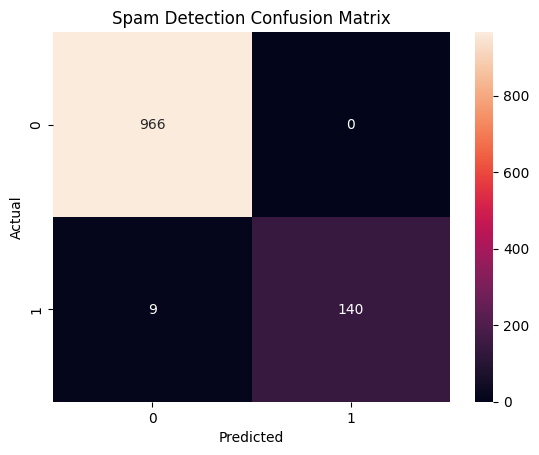

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_count)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Spam Detection Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
from langchain_core.tools import tool

@tool
def detect_spam(message: str) -> str:
    """
    Detect whether a message is spam or ham.
    """

    msg_count = vectorizer.transform([message])

    prediction = model.predict(msg_count)

    if prediction[0] == 1:
        return "Spam Message"
    else:
        return "Ham Message"

In [12]:
from google.colab import userdata
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
WHETHER_API_KEY=userdata.get('WHETHER_API_KEY')


In [13]:
from langchain_groq import ChatGroq
from langchain_core.tools import tool
import requests

In [14]:
from langchain_community.tools import DuckDuckGoSearchRun
search_tool= DuckDuckGoSearchRun()

In [15]:

@tool
def get_weather_data(city: str) -> str:
  """
  This tool fetches the current weather data for a given city
  """
  url = f'https://api.weatherstack.com/current?access_key={WHETHER_API_KEY}&query={city}' # Enter the weatherstack api key before use

  response = requests.get(url)

  return response.json()

In [16]:
llm=ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    groq_api_key=GROQ_API_KEY,
    model_kwargs={"tool_choice":"auto"}
)

In [15]:
!pip install -U langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.7/173.7 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.0.4
    Uninstalling langchain-core-1.0.4:
      Successfully uninstalled langchain-core-1.0.4
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.0.10
    Uninstalling langgraph-1.0.10:
      Successfully uninstalled langgraph-1.0.10
  Attempting uninstall: langchain
    Found existing installation: langchain 1.0.5
    Uninstalling langchain-1.0.5:
      Successfully uninstalled langchain-1.0.5


In [17]:
from langchain.agents import create_agent
from langsmith import Client

In [18]:
from langchain.agents.middleware import dynamic_prompt, ModelRequest

In [19]:
from langsmith import Client
client=Client()
prompt=client.pull_prompt("hwchase17/react")
prompt_template_string=prompt.template

In [20]:
agent = create_agent(
    model=llm,
    tools=[
        search_tool,
        get_weather_data,
        detect_spam   # ADD THIS
    ],
    system_prompt=prompt_template_string
)

In [21]:
response = agent.invoke(
    {"messages": [
        {"role": "user",
         "content": "Check if this message is spam: Free lottery! Click now"}
    ]}
)

print(response['messages'][-1].content)

Question: Check if this message is spam: Free lottery! Click now  
Thought: I need to determine whether the given message is spam.  
Action: detect_spam  
Action Input: { "message": "Free lottery! Click now" }  
Observation: Spam Message  
Thought: I now know the final answer.  
Final Answer: The message is spam.


In [22]:
for messages in response['messages']:
  print(messages)

content='Check if this message is spam: Free lottery! Click now' additional_kwargs={} response_metadata={} id='a331fb8e-2717-4b6d-86cc-f599a5f3c781'
content='' additional_kwargs={'reasoning_content': 'We need to use detect_spam tool.', 'tool_calls': [{'id': 'fc_6760d243-b92d-4317-a241-a25346f3e737', 'function': {'arguments': '{"message":"Free lottery! Click now"}', 'name': 'detect_spam'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 345, 'total_tokens': 383, 'completion_time': 0.043506647, 'completion_tokens_details': {'reasoning_tokens': 10}, 'prompt_time': 0.018518084, 'prompt_tokens_details': None, 'queue_time': 0.002916223, 'total_time': 0.062024731}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3023a70d60', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019dbbb3-64d4-7dd0-b728-f01f8ba103ae-0' tool_calls=[{'name': 'detect_spam', 'args': {'messa

In [23]:
!pip install -q gradio

In [24]:
import gradio as gr

In [25]:
def get_response(query):
  response = agent.invoke(
    {"messages": [{"role": "user", "content": query}]}
  )

  return response['messages'][-1].content

In [26]:
iface = gr.Interface(
    fn=get_response,
    inputs=gr.Textbox(
        label="Ask a question to your AI Agent",
        placeholder="e.g., Find the capital of Madhya Pradesh, then find it's current weather condition",
        lines=2
    ),
    outputs=gr.Textbox(label="Response", lines=10),
    title="AI Agent with Web Access",
    description="This AI Agent has access to the internet. You can ask anything and it will search the web to get you your answer.",
    examples=[
        ["Differentiate between VectorDB and Vector Store"],
        ["What is RAG model?"],
        ["What is the current market cap of NVIDIA"]
    ]
)

In [27]:
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d32065b4d9fa9cd69.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
